# ============================================================
# Healthcare EMR - ADVANCED Model Evaluation (Production Level)
# ============================================================


MODEL PERFORMANCE
Accuracy: 0.5700
Precision: 0.8718
Recall: 0.4722
F1: 0.6126
ROC-AUC: 0.7721


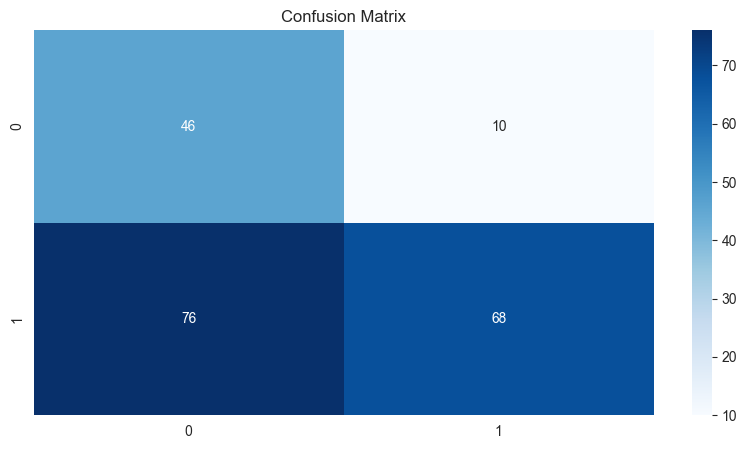

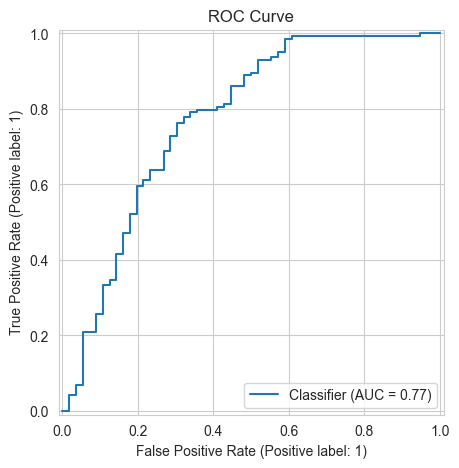

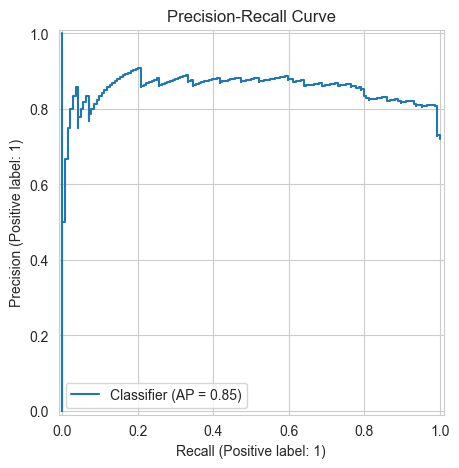

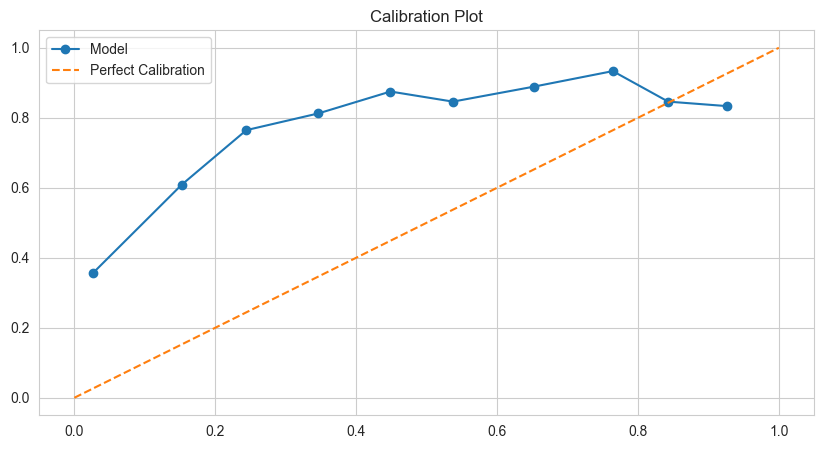

Brier Score (lower is better): 0.2855

BEST THRESHOLD (COST OPTIMIZED):
Threshold        0.100000
Cost         20800.000000
Precision        0.816456
Recall           0.895833
Name: 0, dtype: float64


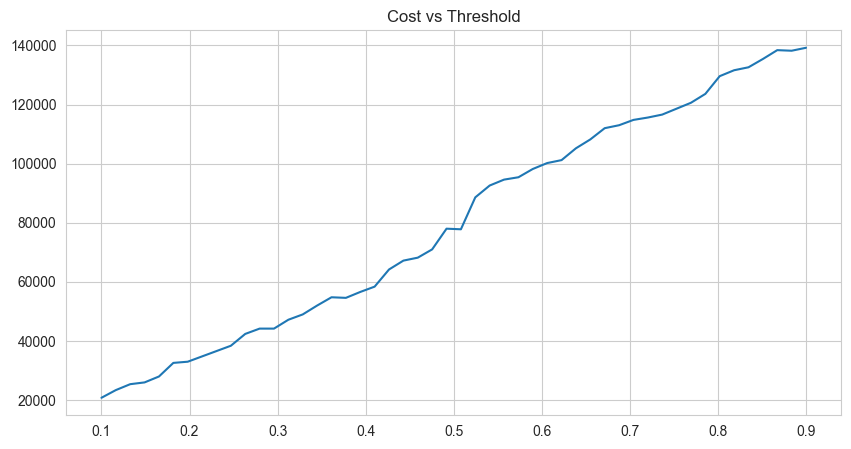


SUBGROUP ANALYSIS
Sex 0 ROC-AUC: 0.7579
Sex 1 ROC-AUC: 0.7790
Insurance 1 ROC-AUC: 0.7781
Insurance 0 ROC-AUC: 0.6296

False Negative Cases: 76
     patient_age  sex_encoded  patient_total_appts  patient_encoded  \
801     0.836640            1                  0.0              266   
807     1.479386            1                  0.0               68   
810    -0.234602            0                  0.0              422   
811    -2.323525            1                  0.0              687   
812    -0.716661            1                  0.0              318   

     patient_cancel_rate  patient_7day_appts  patient_30day_appts  \
801            -0.288831                 0.0                  0.0   
807            -0.288831                 0.0                  0.0   
810            -0.288831                 0.0                  0.0   
811            -0.288831                 0.0                  0.0   
812            -0.288831                 0.0                  0.0   

     patient_

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../dataset/processed/ml_ready_appointments.csv")
df.columns = df.columns.str.strip()

# ============================================================
# 2. LOAD MODEL
# ============================================================

bundle = joblib.load("../models/slot_prediction_model.pkl")

model = bundle["model"]
feature_columns = bundle["feature_columns"]
confirmed_code = bundle["confirmed_code"]

# ============================================================
# 3. TARGET
# ============================================================

df['appointment_success'] = (df['appt_status_encoded'] == confirmed_code).astype(int)

# ============================================================
# 3b. REBUILD ENGINEERED FEATURES (same logic as feature_engineering.ipynb)
# ============================================================

def safe_div(numer, denom):
    numer = np.asarray(numer, dtype=float)
    denom = np.asarray(denom, dtype=float)
    out = np.zeros_like(numer, dtype=float)
    m = denom != 0
    out[m] = numer[m] / denom[m]
    return out

# Synthetic datetime for ordering
df['appt_dt'] = pd.to_datetime(
    {'year': 2026, 'month': df['appt_month'].astype(int),
     'day': df['appt_day'].astype(int), 'hour': df['appt_hour'].astype(int), 'minute': 0},
    errors='coerce'
)
df['_row_id'] = np.arange(len(df))
df = df.sort_values(['appt_dt', '_row_id']).reset_index(drop=True)

# Slot key
df['slot_key'] = df['appt_weekday'].astype(int).astype(str) + '_' + df['appt_hour'].astype(int).astype(str)

# Patient-provider loyalty
if 'patient_provider_history' in df.columns and 'patient_total_appts' in df.columns:
    df['patient_provider_loyalty'] = safe_div(df['patient_provider_history'], df['patient_total_appts'])
else:
    df['patient_provider_loyalty'] = 0.0

# Slot demand / popularity
slot_counts = df.groupby('slot_key').size().rename('slot_demand_count')
df = df.join(slot_counts, on='slot_key')
c = df['slot_demand_count'].astype(float)
df['slot_popularity_score'] = (c - c.min()) / (c.max() - c.min() + 1e-9)
slot_success = df.groupby('slot_key')['appointment_success'].mean().rename('slot_historical_success_rate')
df = df.join(slot_success, on='slot_key')
prov_slot = df.groupby(['provider_encoded', 'slot_key']).size().rename('provider_slot_volume')
df = df.join(prov_slot, on=['provider_encoded', 'slot_key'])

# Expanding historical success rates (shifted)
df['patient_hist_success_rate'] = (
    df.groupby('patient_encoded')['appointment_success']
      .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
      .reset_index(level=0, drop=True)
)
df['provider_hist_success_rate'] = (
    df.groupby('provider_encoded')['appointment_success']
      .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
      .reset_index(level=0, drop=True)
)
pair_key = ['patient_encoded', 'provider_encoded']
df['patient_provider_hist_success_rate'] = (
    df.groupby(pair_key)['appointment_success']
      .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
      .reset_index(level=pair_key, drop=True)
)
df['slot_hist_success_rate_shifted'] = (
    df.groupby('slot_key')['appointment_success']
      .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
      .reset_index(level=0, drop=True)
)
df['patient_hist_appt_count'] = df.groupby('patient_encoded').cumcount()
df['provider_hist_appt_count'] = df.groupby('provider_encoded').cumcount()
df['patient_provider_hist_appt_count'] = df.groupby(pair_key).cumcount()
df['slot_hist_appt_count'] = df.groupby('slot_key').cumcount()
hist_cols = ['patient_hist_success_rate', 'provider_hist_success_rate',
             'patient_provider_hist_success_rate', 'slot_hist_success_rate_shifted']
df[hist_cols] = df[hist_cols].fillna(df['appointment_success'].mean())

# Rolling 7D / 30D features
def add_time_rolling_features(df_in, group_col, time_col, label_col, windows=('7D','30D')):
    df_in = df_in.sort_values([time_col, '_row_id']).reset_index(drop=True).copy()
    global_mean = df_in[label_col].mean()
    out = df_in[[group_col, time_col, label_col]].copy()
    out[label_col] = out.groupby(group_col)[label_col].shift(1)
    out_valid = out.dropna(subset=[time_col]).reset_index(drop=True).copy()
    orig_idx = out.dropna(subset=[time_col]).index.tolist()
    for w in windows:
        rolled = (
            out_valid.groupby(group_col)
                     .rolling(w, on=time_col)[label_col]
                     .agg(['count', 'mean'])
                     .reset_index(level=0, drop=True)
        )
        count_vals = rolled['count'].values
        mean_vals  = rolled['mean'].values
        col_count = np.full(len(df_in), 0.0)
        col_mean  = np.full(len(df_in), global_mean)
        for pos, orig_i in enumerate(orig_idx):
            col_count[orig_i] = count_vals[pos]
            if not np.isnan(mean_vals[pos]):
                col_mean[orig_i] = mean_vals[pos]
        df_in[f'{group_col}_roll_{w}_count'] = col_count
        df_in[f'{group_col}_roll_{w}_success_rate'] = col_mean
    return df_in

df = add_time_rolling_features(df, group_col='patient_encoded', time_col='appt_dt', label_col='appointment_success')
df = add_time_rolling_features(df, group_col='provider_encoded', time_col='appt_dt', label_col='appointment_success')

X = df[feature_columns]
y = df['appointment_success']

# ============================================================
# 4. SPLIT (CONSISTENT)
# ============================================================

split_idx = int(len(df) * 0.8)

X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

# ============================================================
# 5. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
else:
    raise ValueError("Model does not support probability predictions")


# ============================================================
# 6. CORE METRICS
# ============================================================

def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

metrics = evaluate(y_test, y_pred, y_prob)

print("\nMODEL PERFORMANCE")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


# ============================================================
# 8. ROC + PR CURVES
# ============================================================

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("Precision-Recall Curve")
plt.show()


# ============================================================
# 9. CALIBRATION CHECK (VERY IMPORTANT)
# ============================================================

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1],[0,1], linestyle='--', label='Perfect Calibration')
plt.title("Calibration Plot")
plt.legend()
plt.show()

brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score (lower is better): {brier:.4f}")


# ============================================================
# 10. AUTO THRESHOLD OPTIMIZATION (COST BASED)
# ============================================================

cost_fn = 1000
cost_fp = 200

thresholds = np.linspace(0.1, 0.9, 50)
results = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    cost = (fn * cost_fn) + (fp * cost_fp)
    
    results.append([t, cost, precision_score(y_test, preds), recall_score(y_test, preds)])

th_df = pd.DataFrame(results, columns=["Threshold","Cost","Precision","Recall"])

best_t = th_df.loc[th_df["Cost"].idxmin()]

print("\nBEST THRESHOLD (COST OPTIMIZED):")
print(best_t)

plt.plot(th_df["Threshold"], th_df["Cost"])
plt.title("Cost vs Threshold")
plt.show()


# ============================================================
# 11. SUBGROUP ANALYSIS (BIAS CHECK)
# ============================================================

print("\nSUBGROUP ANALYSIS")

if "sex_encoded" in df.columns:
    for group in df["sex_encoded"].unique():
        mask = X_test["sex_encoded"] == group
        if mask.sum() > 0:
            score = roc_auc_score(y_test[mask], y_prob[mask])
            print(f"Sex {group} ROC-AUC: {score:.4f}")

if "has_primary_insurance" in df.columns:
    for group in df["has_primary_insurance"].unique():
        mask = X_test["has_primary_insurance"] == group
        if mask.sum() > 0:
            score = roc_auc_score(y_test[mask], y_prob[mask])
            print(f"Insurance {group} ROC-AUC: {score:.4f}")


# ============================================================
# 12. ERROR ANALYSIS (VERY IMPORTANT)
# ============================================================

errors = X_test.copy()
errors["actual"] = y_test.values
errors["pred"] = y_pred
errors["prob"] = y_prob

# False Negatives (MOST IMPORTANT)
fn_cases = errors[(errors["actual"] == 1) & (errors["pred"] == 0)]

print(f"\nFalse Negative Cases: {len(fn_cases)}")
print(fn_cases.head())


# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

if hasattr(model, "feature_importances_"):
    fi = pd.Series(model.feature_importances_, index=feature_columns)
elif hasattr(model, "coef_"):
    fi = pd.Series(np.abs(model.coef_).flatten(), index=feature_columns)
else:
    fi = None

if fi is not None:
    fi = fi.sort_values(ascending=False)
    fi.head(15).sort_values().plot(kind='barh')
    plt.title("Top Features")
    plt.show()


# ============================================================
# 14. FINAL BUSINESS INSIGHT
# ============================================================

print("\nFINAL INSIGHTS")
print(f"""
- Model ROC-AUC: {metrics['ROC-AUC']:.3f}
- Best Threshold: {best_t['Threshold']:.2f}
- Minimum Cost: ₹{int(best_t['Cost'])}

KEY TAKEAWAY:
→ Use optimized threshold instead of default 0.5
→ Focus on reducing False Negatives (missed patients)
→ Monitor model drift monthly
""")

# ============================================================
# CUSTOM PREDICTION TEST - Input Your Own Data
# ============================================================

## Instructions:
1. Fill in the feature values below with your appointment data
2. Run the cell to get predictions with probability scores
3. Probability > 0.5 = Likely to be CONFIRMED (Success)
4. Probability < 0.5 = Likely to be CANCELLED/RESCHEDULED (Failure)

In [6]:
# ========== INTERACTIVE PREDICTION TESTER ==========
# Enter your appointment data here for quick predictions

import pandas as pd
import numpy as np
import joblib

# Load model bundle explicitly (prevents NameError when cell is run standalone)
bundle = joblib.load("../models/slot_prediction_model.pkl")
model = bundle["model"]
feature_columns = bundle["feature_columns"]

# =====================================================
# STEP 1: FILL IN YOUR FEATURE VALUES BELOW
# =====================================================
# (Adjust these values for your own case)
patient_age = 45
sex_encoded = 1
patient_total_appts = 12
patient_encoded = 5
patient_cancel_rate = 0.15
patient_7day_appts = 2
patient_30day_appts = 5
patient_7day_cancel = 0
patient_30day_cancel = 1
provider_encoded = 3
provider_total_appts = 250
provider_avg_duration = 30
provider_cancel_rate = 0.08
provider_7day_util = 0.85
provider_30day_util = 0.80
duration = 30
appt_weekday = 3
appt_hour = 10
appt_month = 3
appt_day = 15
appt_quarter = 1
is_weekend = 0
is_holiday = 0
is_peak_day = 1
season = 1
lead_time_days = 14
was_updated = 0
visit_reason_encoded = 2
location_encoded = 1
patient_provider_history = 4
has_overlap = 0
has_primary_insurance = 1
has_secondary_insurance = 0
has_dual_insurance = 0
is_medicare = 0
is_medicaid = 0
is_hmo = 1
secondary_insurance_active = 0
insurance_coverage_days = 365
has_copay = 1
patient_avg_copay = 25.0
is_home_visit = 0
is_new_patient = 0
is_established_patient = 1
is_telehealth = 0
is_wellness = 0
is_followup = 1
is_lab = 0
is_emergency = 0
is_paid = 1
paidAmount = 100.0
days_since_last_payment = 5
contact_method_encoded = 1
note_length = 150
insurance_medicalGroup_freq = 5
providerName_freq = 8
serviceLocationName_freq = 12
slot_Morning = 1
slot_Midday = 0
slot_Afternoon = 0
slot_Evening = 0
dur_Short = 0
dur_Medium = 1
dur_Long = 0
note_tfidf_0 = 0.001
note_tfidf_1 = 0.002
note_tfidf_2 = 0.001
note_tfidf_3 = 0.000
note_tfidf_4 = 0.001
note_tfidf_5 = 0.000
note_tfidf_6 = 0.001
note_tfidf_7 = 0.000
note_tfidf_8 = 0.002
reason_tfidf_0 = 0.002
reason_tfidf_1 = 0.001
reason_tfidf_2 = 0.001
reason_tfidf_3 = 0.000
reason_tfidf_4 = 0.001
reason_tfidf_5 = 0.000
reason_tfidf_6 = 0.001
reason_tfidf_7 = 0.002
reason_tfidf_8 = 0.001
reason_tfidf_9 = 0.000
reason_tfidf_10 = 0.001
reason_tfidf_11 = 0.000
reason_tfidf_12 = 0.001
reason_tfidf_13 = 0.002
reason_tfidf_14 = 0.001
reason_tfidf_15 = 0.000
reason_tfidf_16 = 0.001
reason_tfidf_17 = 0.001
reason_tfidf_18 = 0.000

# =====================================================
# STEP 2: BUILD FEATURE DATAFRAME
# =====================================================
base = dict.fromkeys(feature_columns, 0.0)
base.update({
    'patient_age': patient_age,
    'sex_encoded': sex_encoded,
    'patient_total_appts': patient_total_appts,
    'patient_encoded': patient_encoded,
    'patient_cancel_rate': patient_cancel_rate,
    'patient_7day_appts': patient_7day_appts,
    'patient_30day_appts': patient_30day_appts,
    'patient_7day_cancel': patient_7day_cancel,
    'patient_30day_cancel': patient_30day_cancel,
    'provider_encoded': provider_encoded,
    'provider_total_appts': provider_total_appts,
    'provider_avg_duration': provider_avg_duration,
    'provider_cancel_rate': provider_cancel_rate,
    'provider_7day_util': provider_7day_util,
    'provider_30day_util': provider_30day_util,
    'duration': duration,
    'appt_weekday': appt_weekday,
    'appt_hour': appt_hour,
    'appt_month': appt_month,
    'appt_day': appt_day,
    'appt_quarter': appt_quarter,
    'is_weekend': is_weekend,
    'is_holiday': is_holiday,
    'is_peak_day': is_peak_day,
    'season': season,
    'lead_time_days': lead_time_days,
    'was_updated': was_updated,
    'visit_reason_encoded': visit_reason_encoded,
    'location_encoded': location_encoded,
    'patient_provider_history': patient_provider_history,
    'has_overlap': has_overlap,
    'has_primary_insurance': has_primary_insurance,
    'has_secondary_insurance': has_secondary_insurance,
    'has_dual_insurance': has_dual_insurance,
    'is_medicare': is_medicare,
    'is_medicaid': is_medicaid,
    'is_hmo': is_hmo,
    'secondary_insurance_active': secondary_insurance_active,
    'insurance_coverage_days': insurance_coverage_days,
    'has_copay': has_copay,
    'patient_avg_copay': patient_avg_copay,
    'is_home_visit': is_home_visit,
    'is_new_patient': is_new_patient,
    'is_established_patient': is_established_patient,
    'is_telehealth': is_telehealth,
    'is_wellness': is_wellness,
    'is_followup': is_followup,
    'is_lab': is_lab,
    'is_emergency': is_emergency,
    'is_paid': is_paid,
    'paidAmount': paidAmount,
    'contact_method_encoded': contact_method_encoded,
    'note_length': note_length,
    'insurance_medicalGroup_freq': insurance_medicalGroup_freq,
    'providerName_freq': providerName_freq,
    'serviceLocationName_freq': serviceLocationName_freq,
    'slot_Morning': slot_Morning,
    'slot_Midday': slot_Midday,
    'slot_Afternoon': slot_Afternoon,
    'slot_Evening': slot_Evening,
    'dur_Short': dur_Short,
    'dur_Medium': dur_Medium,
    'dur_Long': dur_Long,
    'note_tfidf_0': note_tfidf_0,
    'note_tfidf_1': note_tfidf_1,
    'note_tfidf_2': note_tfidf_2,
    'note_tfidf_3': note_tfidf_3,
    'note_tfidf_4': note_tfidf_4,
    'note_tfidf_5': note_tfidf_5,
    'note_tfidf_6': note_tfidf_6,
    'note_tfidf_7': note_tfidf_7,
    'note_tfidf_8': note_tfidf_8,
    'reason_tfidf_0': reason_tfidf_0,
    'reason_tfidf_1': reason_tfidf_1,
    'reason_tfidf_2': reason_tfidf_2,
    'reason_tfidf_3': reason_tfidf_3,
    'reason_tfidf_4': reason_tfidf_4,
    'reason_tfidf_5': reason_tfidf_5,
    'reason_tfidf_6': reason_tfidf_6,
    'reason_tfidf_7': reason_tfidf_7,
    'reason_tfidf_8': reason_tfidf_8,
    'reason_tfidf_9': reason_tfidf_9,
    'reason_tfidf_10': reason_tfidf_10,
    'reason_tfidf_11': reason_tfidf_11,
    'reason_tfidf_12': reason_tfidf_12,
    'reason_tfidf_13': reason_tfidf_13,
    'reason_tfidf_14': reason_tfidf_14,
    'reason_tfidf_15': reason_tfidf_15,
    'reason_tfidf_16': reason_tfidf_16,
    'reason_tfidf_17': reason_tfidf_17,
    'reason_tfidf_18': reason_tfidf_18,
})

# Any left-out engineered features remain default 0.0 in this test row
for c in feature_columns:
    if c not in base:
        base[c] = 0.0

# Create input row in precise model order
test_sample = pd.DataFrame([base], columns=feature_columns)

print("="*70)
print("APPOINTMENT SLOT PREDICTION - TEST YOUR DATA")
print("="*70)

# =====================================================
# STEP 3: MAKE PREDICTIONS
# =====================================================

y_pred_prob = model.predict_proba(test_sample)[0]
print(y_pred_prob)
prob_failure = y_pred_prob[0]
prob_success = y_pred_prob[1]

print("\nPROBABILITY OF SUCCESS (CONFIRMED):", f"{prob_success:.2%}")
print("PROBABILITY OF FAILURE (CANCELLED/RESCHEDULED):", f"{prob_failure:.2%}")

if prob_success > 0.7:
    print("🟢 HIGH CONFIDENCE: Appointment likely to be CONFIRMED")
elif prob_success > 0.5:
    print("🟡 MODERATE CONFIDENCE: Appointment likely to be CONFIRMED")
else:
    print("🔴 HIGH RISK: Appointment likely to be CANCELLED/RESCHEDULED")


APPOINTMENT SLOT PREDICTION - TEST YOUR DATA
[0. 1.]

PROBABILITY OF SUCCESS (CONFIRMED): 100.00%
PROBABILITY OF FAILURE (CANCELLED/RESCHEDULED): 0.00%
🟢 HIGH CONFIDENCE: Appointment likely to be CONFIRMED
